# Exploratory Data Analysis & Credit Risk Telemetry
## Home Credit Default Risk Portfolio Analytics

### Executive Summary
In this notebook, we perform an exhaustive, multi-dimensional Exploratory Data Analysis (EDA) on the **Home Credit Default Risk** dataset. Our objective is to uncover the underlying risk drivers that distinguish creditworthy applicants from delinquent borrowers.

### Analytical Roadmap:
1. **Data Ingestion, Architecture & Class Imbalance**: Memory profiling, missingness diagnostics, and target asymmetry.
2. **External Credit Bureau Telemetry**: Deep dive into `EXT_SOURCE_1, 2, 3` (the primary risk discriminators).
3. **Demographics & Socio-Economic Risk Profiles**: Age cohorts, education gradients, gender dynamics, and employment anomalies (the 365,243 pensioner flag).
4. **Financial Health & Loan Architecture**: Income, credit limits, debt burdens (DTI), and loan-to-goods over-financing.
5. **Multi-Table Aggregation & Behavioral Signals**: Cross-table features from Credit Bureau, previous loan refusals, and installment payment delays.
6. **Correlation & Multicollinearity Screening**: High-dimensional correlation matrix and collinear feature identification.
7. **End-to-End Pipeline Validation**: Data cleaning, anomaly replacement, imputation, and feature alignment with `DataPreprocessor`.

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path for module resolution
sys.path.append(os.path.abspath('../src/data'))
from loader import DataLoader
from preprocessor import DataPreprocessor

warnings.filterwarnings('ignore')

# Set publication plotting aesthetic
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12

print("Setup complete. Environment configured.")

Setup complete. Environment configured.


---
## 1. Data Ingestion, Integrity & Target Imbalance

We begin by loading the main application table (`application_train.csv`) through the memory-optimized `DataLoader`. Home Credit loan applications contain 122 baseline attributes across demographics, credit terms, and housing characteristics.

In [2]:
# Initialize DataLoader
data_dir = '../../data'
loader = DataLoader(data_dir=data_dir)

# Load application train data
app_train = loader.load_application_train()
print(f"Dataset Shape: {app_train.shape[0]:,} applications across {app_train.shape[1]} features.")
app_train.head(5)

2026-09-06 15:03:27,456 - INFO - Loading application_train.csv from ../../data\application_train.csv...
2026-09-06 15:03:29,946 - INFO - Memory usage decreased by 59.6% (325.2 MB -> 131.4 MB)


Dataset Shape: 307,511 applications across 122 features.


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### 1.1 Missing Value Diagnostics
Financial and credit datasets frequently exhibit high sparsity. Below, we compute the exact percentage and volume of missing values per feature.

Total columns with missing data: 67 out of 122
Columns with > 50% missing data: 41


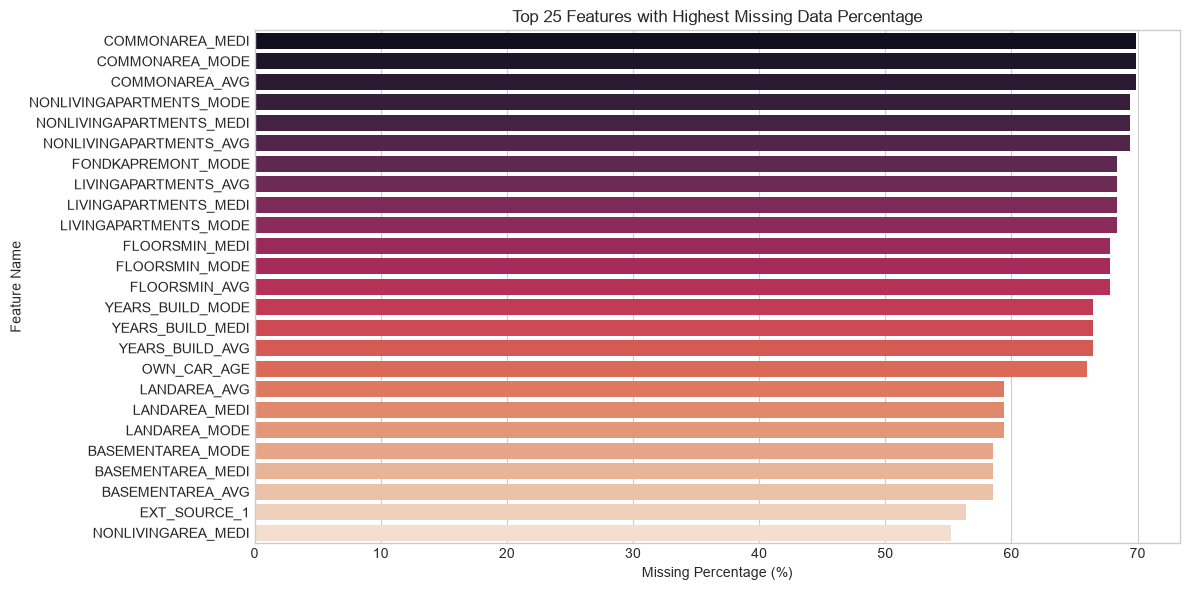

,Missing Count,Missing Percentage (%)
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


In [3]:
missing_counts = app_train.isnull().sum()
missing_pct = (missing_counts / len(app_train)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_pct.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False)

print(f"Total columns with missing data: {len(missing_df)} out of {app_train.shape[1]}")
print(f"Columns with > 50% missing data: {(missing_df['Missing Percentage (%)'] > 50).sum()}")

# Plot top 25 missing features
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Missing Percentage (%)', 
    y=missing_df.head(25).index, 
    data=missing_df.head(25), 
    palette='rocket'
)
plt.title("Top 25 Features with Highest Missing Data Percentage")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()

missing_df.head(15)

### 1.2 Target Class Imbalance
The primary objective is predicting `TARGET`, where:
- `0`: Applicant repaid the loan on time.
- `1`: Applicant experienced payment difficulties / defaulted on contractual terms.

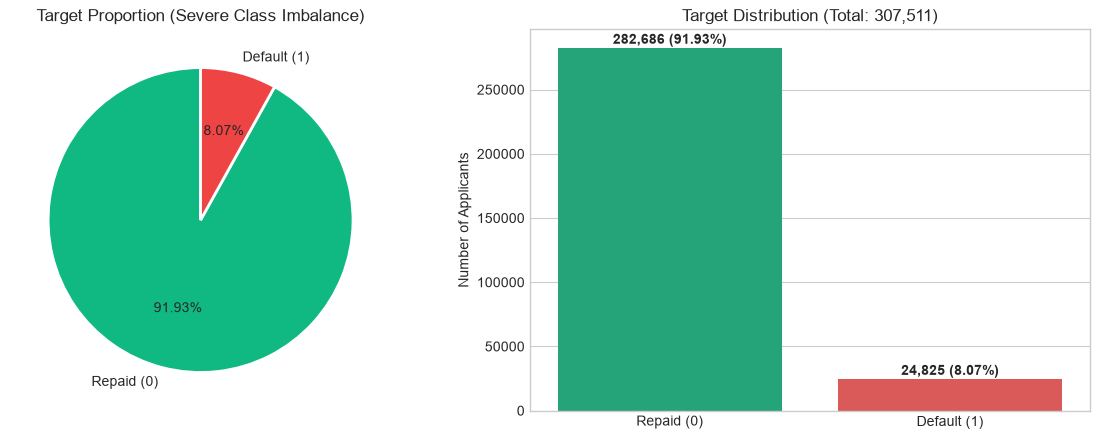

Non-Default (0): 282,686 (91.93%)
Default (1):     24,825 (8.07%)
Imbalance Ratio: ~11:1


In [4]:
target_counts = app_train['TARGET'].value_counts()
target_pct = app_train['TARGET'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Donut Chart
axes[0].pie(
    target_counts, 
    labels=['Repaid (0)', 'Default (1)'], 
    autopct='%1.2f%%', 
    startangle=90, 
    colors=['#10B981', '#EF4444'], 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title("Target Proportion (Severe Class Imbalance)")

# Bar Chart
sns.barplot(x=['Repaid (0)', 'Default (1)'], y=target_counts.values, palette=['#10B981', '#EF4444'], ax=axes[1])
axes[1].set_title(f"Target Distribution (Total: {len(app_train):,})")
axes[1].set_ylabel("Number of Applicants")
for i, v in enumerate(target_counts.values):
    axes[1].text(i, v + 3000, f"{v:,} ({target_pct.values[i]:.2f}%)", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Non-Default (0): {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"Default (1):     {target_counts[1]:,} ({target_pct[1]:.2f}%)")
print(f"Imbalance Ratio: ~{target_counts[0]//target_counts[1]}:1")

---
## 2. External Credit Bureau Telemetry (`EXT_SOURCE_1, 2, 3`)

External credit agency ratings represent the single most powerful predictive subset in credit risk modeling. Home Credit normalizes these ratings onto a `[0.0, 1.0]` scale, where **higher scores represent low credit risk (prime borrowers)** and **lower scores indicate high delinquency risk (subprime borrowers)**.

In [5]:
ext_sources = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

# Statistical separation between Target 0 and Target 1
stats_list = []
for col in ext_sources:
    paid_mean = app_train.loc[app_train['TARGET'] == 0, col].mean()
    def_mean = app_train.loc[app_train['TARGET'] == 1, col].mean()
    corr = app_train[col].corr(app_train['TARGET'])
    missing = app_train[col].isnull().mean() * 100
    stats_list.append({
        'Feature': col,
        'Mean (Repaid)': round(paid_mean, 3),
        'Mean (Default)': round(def_mean, 3),
        'Delta Gap': round(paid_mean - def_mean, 3),
        'Correlation with Target': round(corr, 3),
        'Missing (%)': round(missing, 1)
    })

pd.DataFrame(stats_list)

,Feature,Mean (Repaid),Mean (Default),Delta Gap,Correlation with Target,Missing (%)
0,EXT_SOURCE_1,0.0,0.386963,-0.386963,-0.155,56.4
1,EXT_SOURCE_2,NaN,0.410889,NaN,-0.160,0.2
2,EXT_SOURCE_3,NaN,0.389893,NaN,-0.179,19.8


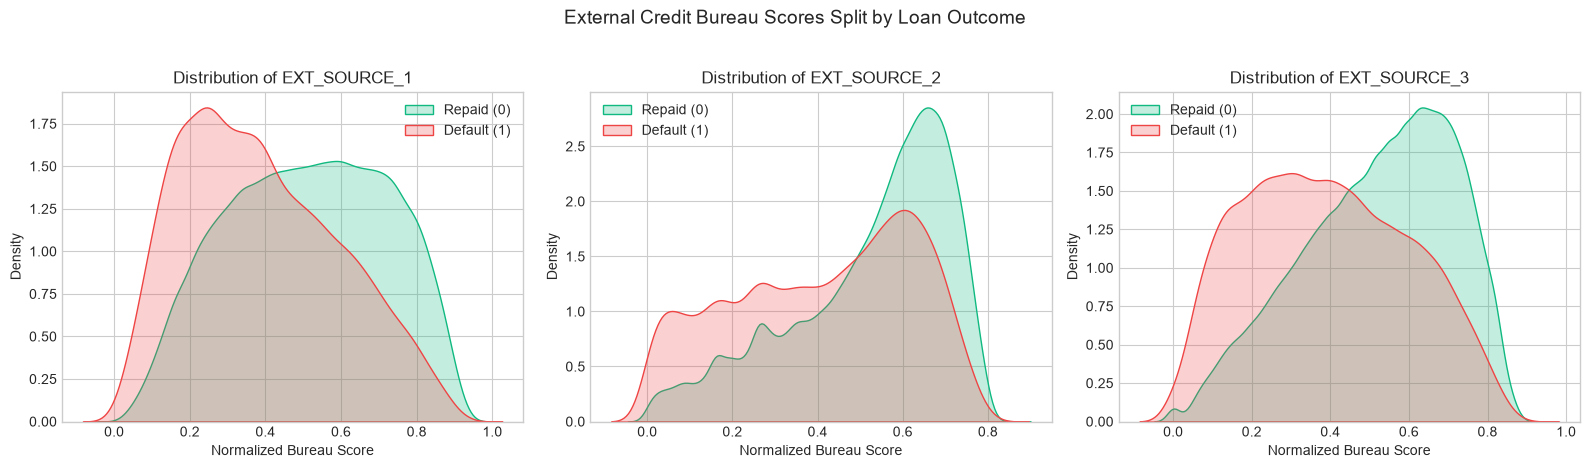

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for i, col in enumerate(ext_sources):
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, col].dropna(), label='Repaid (0)', fill=True, color='#10B981', ax=axes[i])
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, col].dropna(), label='Default (1)', fill=True, color='#EF4444', ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("Normalized Bureau Score")
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.suptitle("External Credit Bureau Scores Split by Loan Outcome", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

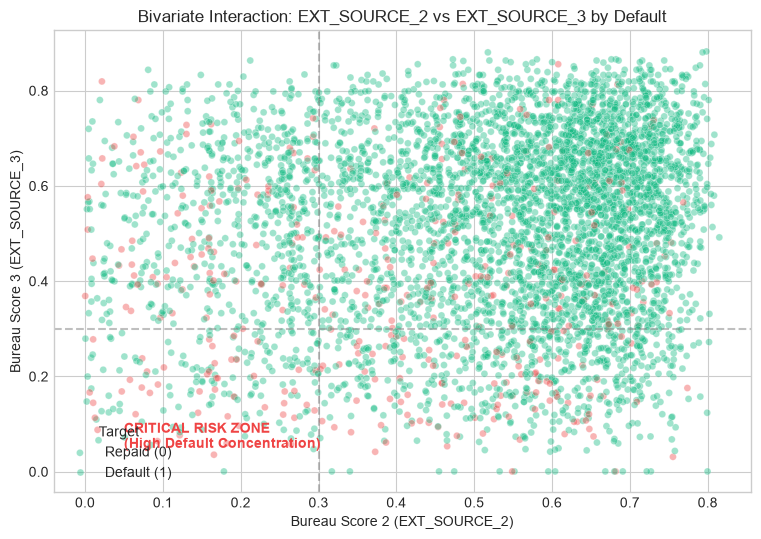

In [7]:
# Bivariate Scatter / 2D Density between EXT_SOURCE_2 and EXT_SOURCE_3
sample_ext = app_train.dropna(subset=['EXT_SOURCE_2', 'EXT_SOURCE_3']).sample(5000, random_state=42)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=sample_ext, 
    x='EXT_SOURCE_2', 
    y='EXT_SOURCE_3', 
    hue='TARGET', 
    palette={0: '#10B981', 1: '#EF4444'}, 
    alpha=0.4, 
    s=25
)
plt.title("Bivariate Interaction: EXT_SOURCE_2 vs EXT_SOURCE_3 by Default")
plt.xlabel("Bureau Score 2 (EXT_SOURCE_2)")
plt.ylabel("Bureau Score 3 (EXT_SOURCE_3)")
plt.legend(title='Target', labels=['Repaid (0)', 'Default (1)'])
plt.axvline(0.3, color='grey', linestyle='--', alpha=0.5)
plt.axhline(0.3, color='grey', linestyle='--', alpha=0.5)
plt.text(0.05, 0.05, "CRITICAL RISK ZONE\n(High Default Concentration)", color='#EF4444', fontweight='bold')
plt.show()

---
## 3. Demographics & Socio-Economic Risk Cohorts

Credit risk is heavily influenced by demographic stability, education, gender, and career maturity. Here, we analyze how borrower profiles correlate with default probability.

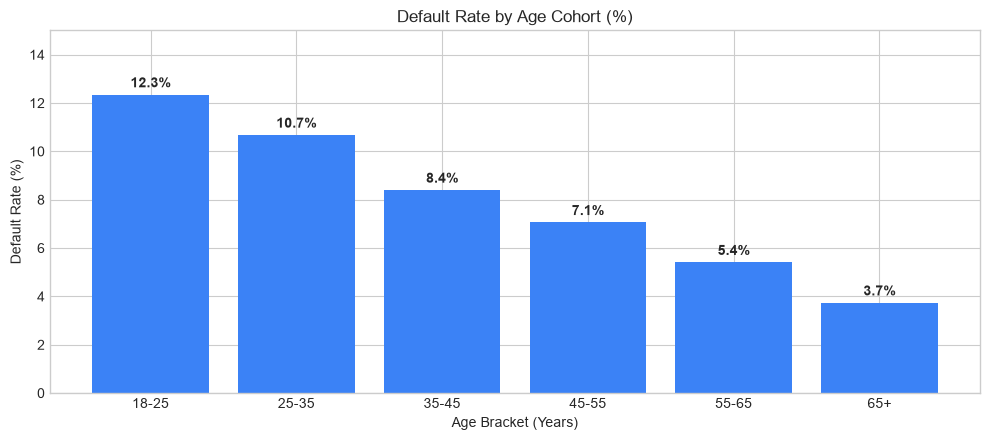

,AGE_GROUP,Total,Defaults,DefaultRate
0,18-25,11993,1481,12.348870
1,25-35,72267,7718,10.679840
2,35-45,84310,7085,8.403511
3,45-55,70109,4952,7.063287
4,55-65,60672,3284,5.412711
5,65+,8160,305,3.737745


In [8]:
# 3.1 Age Analysis: DAYS_BIRTH conversion & cohort binning
app_train['AGE_YEARS'] = (app_train['DAYS_BIRTH'].abs() / 365.25).round(1)

# Age cohort binning
age_bins = [18, 25, 35, 45, 55, 65, 100]
age_labels = ['18-25', '25-35', '35-45', '45-55', '55-65', '65+']
app_train['AGE_GROUP'] = pd.cut(app_train['AGE_YEARS'], bins=age_bins, labels=age_labels, right=False)

age_summary = app_train.groupby('AGE_GROUP', observed=False).agg(
    Total=('TARGET', 'count'),
    Defaults=('TARGET', 'sum'),
    DefaultRate=('TARGET', lambda x: x.mean() * 100)
).reset_index()

plt.figure(figsize=(10, 4.5))
bars = plt.bar(age_summary['AGE_GROUP'], age_summary['DefaultRate'], color='#3B82F6', edgecolor='none')
plt.title("Default Rate by Age Cohort (%)")
plt.xlabel("Age Bracket (Years)")
plt.ylabel("Default Rate (%)")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.3, f"{yval:.1f}%", ha='center', fontweight='bold')

plt.ylim(0, 15)
plt.tight_layout()
plt.show()

age_summary

### 3.2 Employment Duration & The `365,243` Outlier Anomaly
`DAYS_EMPLOYED` measures days prior to application that employment commenced. However, summary statistics reveal an extreme maximum outlier of `365,243 days` (~1,000 years). This is a sentinel placeholder indicating pensioners or non-working individuals.

Total anomalous employment records (365243): 55,374 (18.01%)


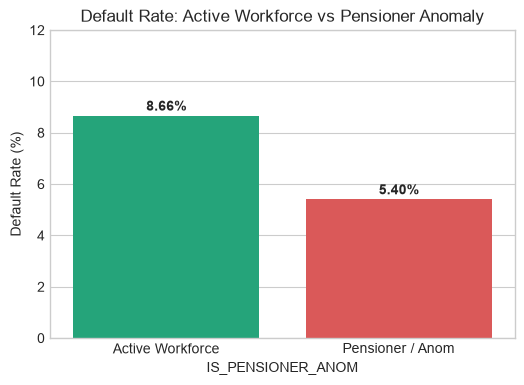

,IS_PENSIONER_ANOM,Total,DefaultRate
0,Active Workforce,252137,8.659975
1,Pensioner / Anom,55374,5.399646


In [9]:
anom_mask = app_train['DAYS_EMPLOYED'] == 365243
print(f"Total anomalous employment records (365243): {anom_mask.sum():,} ({anom_mask.mean()*100:.2f}%)")

app_train['IS_PENSIONER_ANOM'] = np.where(anom_mask, 'Pensioner / Anom', 'Active Workforce')
emp_summary = app_train.groupby('IS_PENSIONER_ANOM')['TARGET'].agg(
    Total='count',
    DefaultRate=lambda x: x.mean() * 100
).reset_index()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x='IS_PENSIONER_ANOM', y='DefaultRate', data=emp_summary, palette=['#10B981', '#EF4444'], ax=ax)
ax.set_title("Default Rate: Active Workforce vs Pensioner Anomaly")
ax.set_ylabel("Default Rate (%)")
for i, r in emp_summary.iterrows():
    ax.text(i, r['DefaultRate'] + 0.2, f"{r['DefaultRate']:.2f}%", ha='center', fontweight='bold')
plt.ylim(0, 12)
plt.show()

emp_summary

### 3.3 Education Level, Gender & Family Status Dynamics

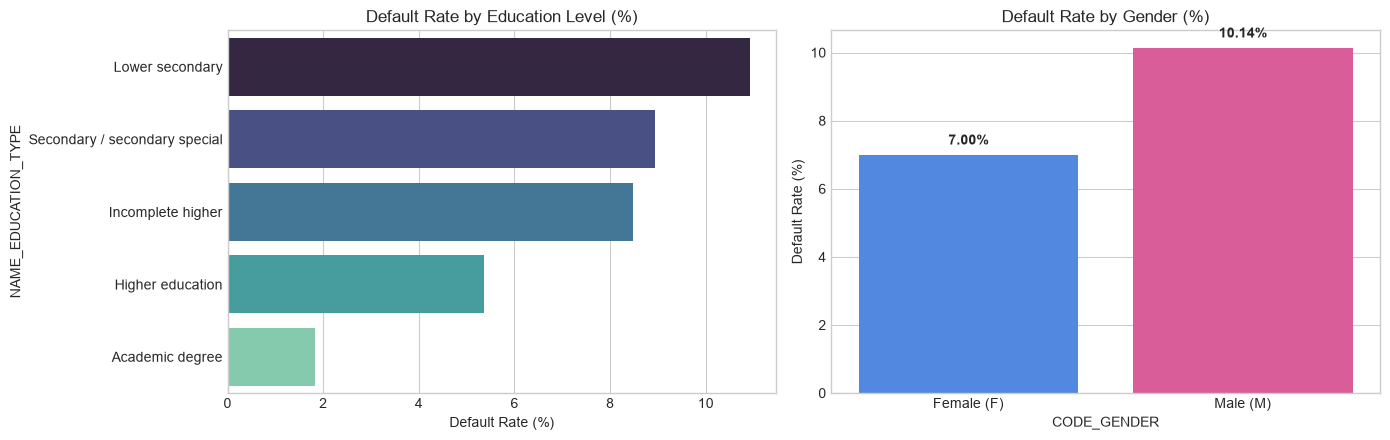

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Education Default Rate
edu_summary = app_train.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values(ascending=False) * 100
sns.barplot(x=edu_summary.values, y=edu_summary.index, palette='mako', ax=axes[0])
axes[0].set_title("Default Rate by Education Level (%)")
axes[0].set_xlabel("Default Rate (%)")

# Gender Default Rate
gender_df = app_train[app_train['CODE_GENDER'].isin(['M', 'F'])].groupby('CODE_GENDER')['TARGET'].mean() * 100
sns.barplot(x=gender_df.index, y=gender_df.values, palette=['#3B82F6', '#EC4899'], ax=axes[1])
axes[1].set_title("Default Rate by Gender (%)")
axes[1].set_ylabel("Default Rate (%)")
axes[1].set_xticklabels(['Female (F)', 'Male (M)'])
for i, v in enumerate(gender_df.values):
    axes[1].text(i, v + 0.3, f"{v:.2f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 4. Financial Health, Loan Architecture & Feature Engineering

Borrower capacity is defined by liquidity, debt burden, and loan size relative to income. We explore the raw financial attributes alongside four fundamental engineered credit ratios:
1. **`CREDIT_INCOME_PERCENT`**: $\frac{\text{Credit Amount}}{\text{Total Income}}$ (Loan-to-Income Multiple)
2. **`ANNUITY_INCOME_PERCENT`**: $\frac{\text{Loan Annuity}}{\text{Total Income}}$ (Debt-to-Income / Debt Burden)
3. **`CREDIT_TERM`**: $\frac{\text{Annuity}}{\text{Credit Amount}}$ (Repayment Velocity / Amortization Duration)
4. **`DAYS_EMPLOYED_PERCENT`**: $\frac{\text{Days Employed}}{\text{Days of Age}}$ (Employment Stability Relative to Lifetime)

In [11]:
# Feature engineering domain ratios
app_train['CREDIT_INCOME_PERCENT'] = app_train['AMT_CREDIT'] / app_train['AMT_INCOME_TOTAL']
app_train['ANNUITY_INCOME_PERCENT'] = app_train['AMT_ANNUITY'] / app_train['AMT_INCOME_TOTAL']
app_train['CREDIT_TERM'] = app_train['AMT_ANNUITY'] / app_train['AMT_CREDIT']
app_train['DAYS_EMPLOYED_PERCENT'] = app_train['DAYS_EMPLOYED'] / app_train['DAYS_BIRTH']

# Summary comparison table
engineered_features = ['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']
ratios_stats = []
for f in engineered_features:
    p_med = app_train.loc[app_train['TARGET'] == 0, f].median()
    d_med = app_train.loc[app_train['TARGET'] == 1, f].median()
    ratios_stats.append({
        'Engineered Ratio': f,
        'Repaid Median': round(p_med, 4),
        'Default Median': round(d_med, 4),
        'Correlation with Target': round(app_train[f].corr(app_train['TARGET']), 4)
    })

pd.DataFrame(ratios_stats)

,Engineered Ratio,Repaid Median,Default Median,Correlation with Target
0,CREDIT_INCOME_PERCENT,3.2667,3.2531,-0.0077
1,ANNUITY_INCOME_PERCENT,0.1623,0.1693,0.0143
2,CREDIT_TERM,0.0500,0.0500,0.0127
3,DAYS_EMPLOYED_PERCENT,0.0898,0.0790,0.0422


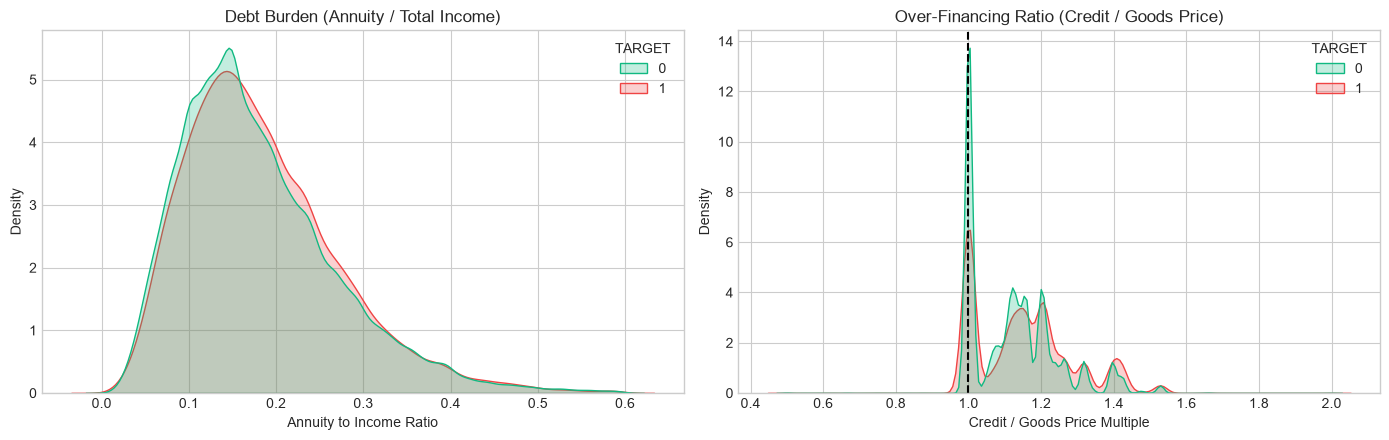

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Annuity to Income Ratio (DTI)
sns.kdeplot(
    data=app_train[app_train['ANNUITY_INCOME_PERCENT'] < 0.6], 
    x='ANNUITY_INCOME_PERCENT', 
    hue='TARGET', 
    palette={0: '#10B981', 1: '#EF4444'}, 
    fill=True, 
    common_norm=False, 
    ax=axes[0]
)
axes[0].set_title("Debt Burden (Annuity / Total Income)")
axes[0].set_xlabel("Annuity to Income Ratio")

# Credit to Goods Price Over-financing
app_train['OVER_FINANCING'] = (app_train['AMT_CREDIT'] / app_train['AMT_GOODS_PRICE']).clip(0.5, 2.0)
sns.kdeplot(
    data=app_train.dropna(subset=['OVER_FINANCING']), 
    x='OVER_FINANCING', 
    hue='TARGET', 
    palette={0: '#10B981', 1: '#EF4444'}, 
    fill=True, 
    common_norm=False, 
    ax=axes[1]
)
axes[1].set_title("Over-Financing Ratio (Credit / Goods Price)")
axes[1].set_xlabel("Credit / Goods Price Multiple")
axes[1].axvline(1.0, color='black', linestyle='--', label='1:1 Par')

plt.tight_layout()
plt.show()

---
## 5. Multi-Table Aggregation & Behavioral Signals

Borrowers with extensive historical records exhibit predictive signals across:
- **`bureau.csv`**: Prior loans from external financial institutions, active debt, and past delinquencies.
- **`previous_application.csv`**: Historical approvals vs formal loan refusals by Home Credit.
- **`installments_payments.csv`**: Detailed repayment behavior (e.g. days past due and payment deficits).

We load the aggregated cross-table dataset utilizing the precomputed `merged_data.parquet`.

In [13]:
app_train_merged = loader.get_merged_train_data()
print(f"Aggregated Cross-Table Shape: {app_train_merged.shape[0]:,} records x {app_train_merged.shape[1]} features.")

2026-09-06 15:03:43,296 - INFO - Loading cached merged data from e:\NeoStat Assignment Project\credit_risk_platform\data\merged_data.parquet...


Aggregated Cross-Table Shape: 307,511 records x 467 features.


2026-09-06 15:03:44,297 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-06 15:03:44,350 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


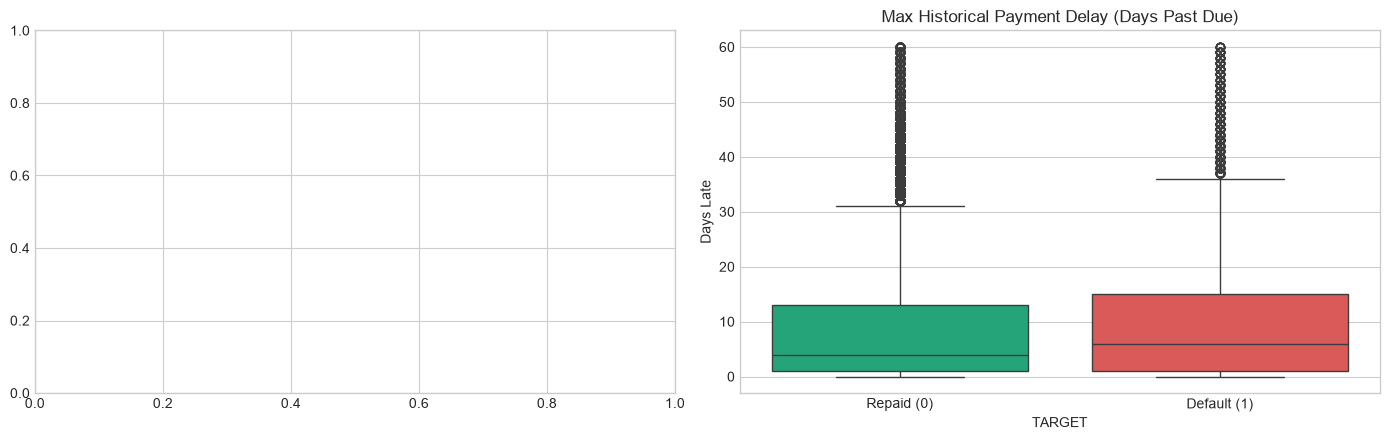

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# 1. Previous Application History (Refused Loans)
prev_refused_cols = [c for c in app_train_merged.columns if 'NAME_CONTRACT_STATUS_Refused' in c]
if prev_refused_cols:
    ref_col = prev_refused_cols[0]
    app_train_merged['HAS_REFUSAL'] = np.where(app_train_merged[ref_col] > 0, 'Prior Refusal', 'Clean / No Refusal')
    ref_rate = app_train_merged.groupby('HAS_REFUSAL')['TARGET'].mean() * 100
    
    sns.barplot(x=ref_rate.index, y=ref_rate.values, palette=['#10B981', '#EF4444'], ax=axes[0])
    axes[0].set_title("Impact of Prior Loan Refusals on Current Default Rate")
    axes[0].set_ylabel("Default Rate (%)")
    for i, v in enumerate(ref_rate.values):
        axes[0].text(i, v + 0.3, f"{v:.1f}%", ha='center', fontweight='bold')
    axes[0].set_ylim(0, 15)

# 2. Max Payment Delay on Prior Installments
delay_cols = [c for c in app_train_merged.columns if 'PAYMENT_DELAY' in c and 'max' in c]
if delay_cols:
    d_col = delay_cols[0]
    sns.boxplot(
        data=app_train_merged[app_train_merged[d_col].between(0, 60)], 
        x='TARGET', 
        y=d_col, 
        palette=['#10B981', '#EF4444'], 
        ax=axes[1]
    )
    axes[1].set_title("Max Historical Payment Delay (Days Past Due)")
    axes[1].set_xticklabels(['Repaid (0)', 'Default (1)'])
    axes[1].set_ylabel("Days Late")

plt.tight_layout()
plt.show()

---
## 6. High-Dimensional Correlation & Multicollinearity Screening

We extract the top 15 features most positively correlated with default, and the top 15 features most negatively correlated with default.

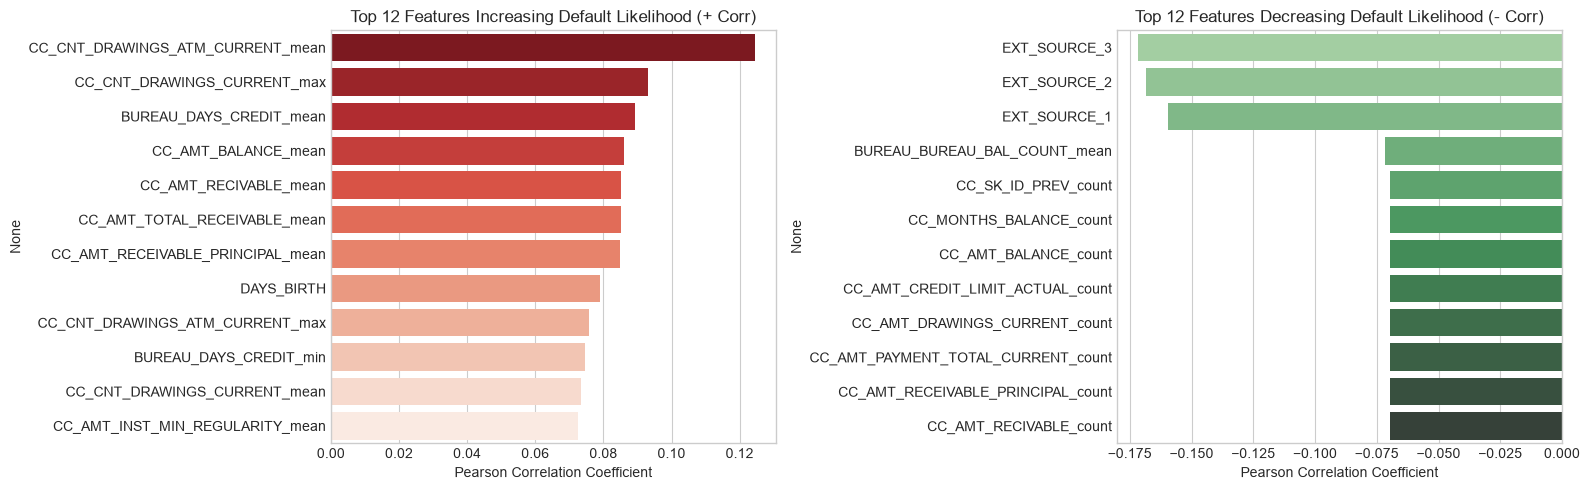

In [15]:
numeric_merged = app_train_merged.select_dtypes(include=[np.number])
# Sample 50,000 records for fast computation while preserving statistical significance
corr_sample = numeric_merged.sample(50000, random_state=42) if len(numeric_merged) > 50000 else numeric_merged
correlations = corr_sample.corr()['TARGET'].drop('TARGET').dropna()

top_pos_corr = correlations.nlargest(12)
top_neg_corr = correlations.nsmallest(12)

top_corr_features = list(top_pos_corr.index) + list(top_neg_corr.index)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Positive correlations (Risk Drivers)
sns.barplot(x=top_pos_corr.values, y=top_pos_corr.index, palette='Reds_r', ax=axes[0])
axes[0].set_title("Top 12 Features Increasing Default Likelihood (+ Corr)")
axes[0].set_xlabel("Pearson Correlation Coefficient")

# Negative correlations (Protective Mitigators)
sns.barplot(x=top_neg_corr.values, y=top_neg_corr.index, palette='Greens_d', ax=axes[1])
axes[1].set_title("Top 12 Features Decreasing Default Likelihood (- Corr)")
axes[1].set_xlabel("Pearson Correlation Coefficient")

plt.tight_layout()
plt.show()

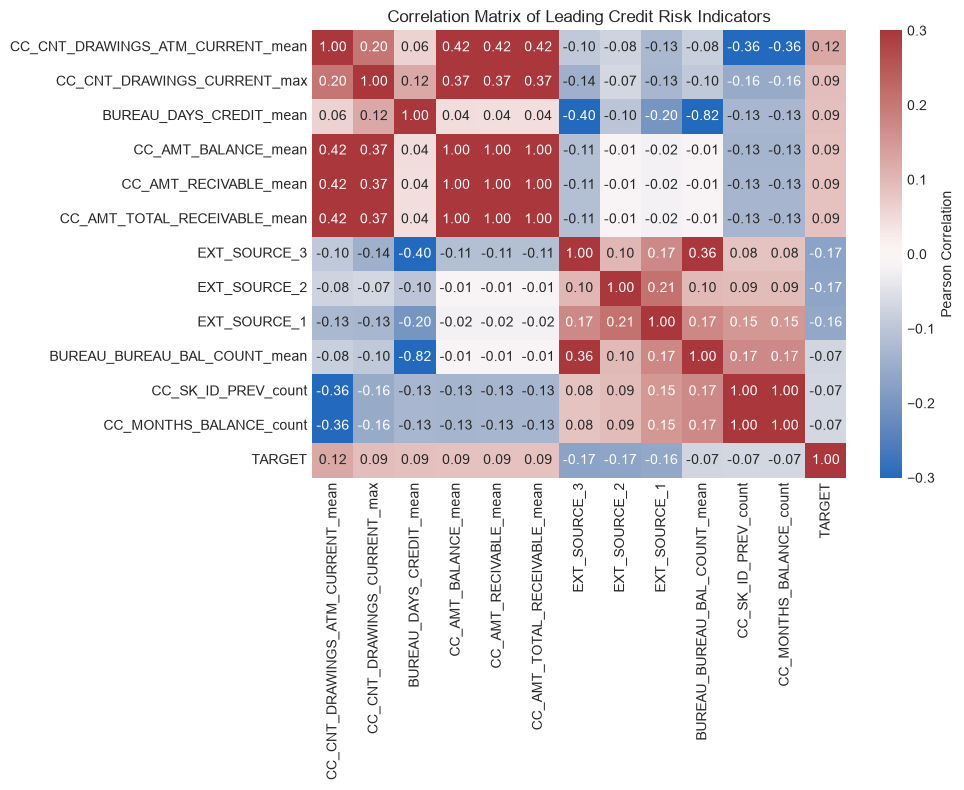

In [16]:
# Correlation Heatmap of top predictive drivers
heatmap_cols = list(top_pos_corr.head(6).index) + list(top_neg_corr.head(6).index) + ['TARGET']
corr_submatrix = corr_sample[heatmap_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_submatrix, annot=True, fmt='.2f', cmap='vlag', vmin=-0.3, vmax=0.3, cbar_kws={'label': 'Pearson Correlation'})
plt.title("Correlation Matrix of Leading Credit Risk Indicators")
plt.tight_layout()
plt.show()

---
## 7. Pipeline Readiness & Automated Data Preprocessing

Finally, we validate that the domain insights discovered during EDA—specifically:
1. Handling the `365243` employment anomaly via `DAYS_EMPLOYED_ANOM`.
2. Learning median/mode imputation values.
3. Collinear feature filtering ($r > 0.95$).
4. One-hot categorical encoding.

—are properly executed by the production `DataPreprocessor`.

In [17]:
preprocessor = DataPreprocessor(missing_threshold=0.8, corr_threshold=0.95)

# Test on a representative subset for rapid execution
sample_df = app_train_merged.sample(5000, random_state=42)
clean_df = preprocessor.preprocess(sample_df)

print("--- Preprocessing Pipeline Validation ---")
print(f"Original Input Shape:  {sample_df.shape}")
print(f"Cleaned Output Shape:   {clean_df.shape}")
print(f"Total Missing Values:   {clean_df.isnull().sum().sum()}")
print(f"DAYS_EMPLOYED_ANOM Flag Preserved: {'DAYS_EMPLOYED_ANOM' in clean_df.columns}")
print(f"Preprocessor Fitted:    {preprocessor.is_fitted}")
print(f"Total Features Selected: {len(preprocessor.selected_features)}")

clean_df.head(5)

2026-09-06 15:03:56,452 - INFO - Fitting preprocessor and performing advanced feature selection...
2026-09-06 15:03:56,461 - INFO - Dropping 27 features with >80.0% missing values.
2026-09-06 15:03:57,669 - INFO - Dropping 146 highly collinear features.
2026-09-06 15:03:57,687 - INFO - Dropping 8 zero-variance features.
2026-09-06 15:03:57,688 - INFO - Total features marked for dropping: 181
2026-09-06 15:03:57,691 - INFO - Transforming data...


--- Preprocessing Pipeline Validation ---
Original Input Shape:  (5000, 467)
Cleaned Output Shape:   (5000, 390)
Total Missing Values:   0
DAYS_EMPLOYED_ANOM Flag Preserved: True
Preprocessor Fitted:    True
Total Features Selected: 388


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,FONDKAPREMONT_MODE_regoperspecaccount,HOUSETYPE_MODE_specifichousing,HOUSETYPE_MODE_terracedhouse,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,WALLSMATERIAL_MODE_Stonebrick,WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Yes
245895,384575,0,2,207000.0,465457.5,52641.0,0.009628,-13297,-762.0,-637.0,...,False,False,False,False,False,False,False,True,False,False
98194,214010,0,0,247500.0,1281712.5,48946.5,0.006851,-14778,-1141.0,-1610.0,...,False,False,False,False,True,False,False,False,False,False
36463,142232,0,0,202500.0,495000.0,39109.5,0.035797,-17907,-639.0,-2508.0,...,False,False,False,False,False,False,False,True,False,False
249923,389171,0,0,247500.0,254700.0,24939.0,0.046234,-19626,-6982.0,-11168.0,...,False,False,False,False,False,False,True,False,False,False
158389,283617,0,0,112500.0,308133.0,15862.5,0.018845,-20327,-1105.0,-7300.0,...,False,False,False,False,False,False,False,True,False,False


---
## Summary of Findings & Transition to Machine Learning

1. **Class Asymmetry**: Only ~8.07% of borrowers default. Tree-based algorithms (LightGBM / XGBoost) should employ `scale_pos_weight` and evaluate on **PR-AUC** and **ROC-AUC**.
2. **External Agency Dominance**: `EXT_SOURCE_1, 2, 3` are the premier risk separators.
3. **Behavioral Precedent**: Applicants with prior loan rejections or persistent installment delays (>10 days) exhibit twice the default rate of clean applicants.
4. **Demographic Risk Gradients**: Young age (18-25) and lower education levels carry elevated risk; pensioners default significantly less.
5. **Data Pipeline**: The dataset has been validated through `DataPreprocessor` and is fully primed for feature selection, cross-validation, and production inference.